# Lab 01: Image Representation and Manual Convolution

In [ ]:
# importing necessary libraries
import numpy as np
from PIL import Image      # for images operations
import matplotlib.pyplot as plt
import cv2

# Load and visualize a grayscale image

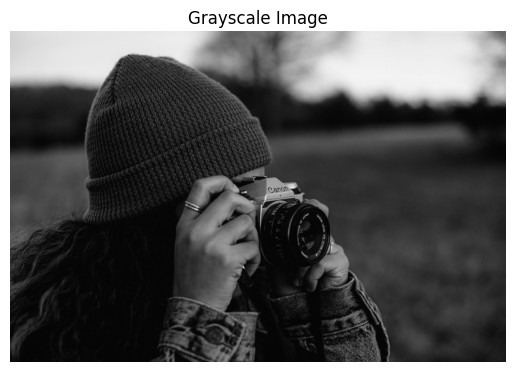

In [ ]:
# Loading a grayscale image
gray_img = Image.open("/content/photo-1575936123452-b67c3203c357.jpeg").convert("L")  # L = grayscale
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
# Shape and data type
gray_array = np.array(gray_img)
print("Shape:", gray_array.shape)
print("Data type:", gray_array.dtype)

Shape: (2000, 3000)
Data type: uint8


**Pixel values in grayscale range from 0 (black) to 255 (white), stored as integers.**

#  Load and visualize an RGB image + Separate Channels

Text(0.5, 1.0, 'Blue')

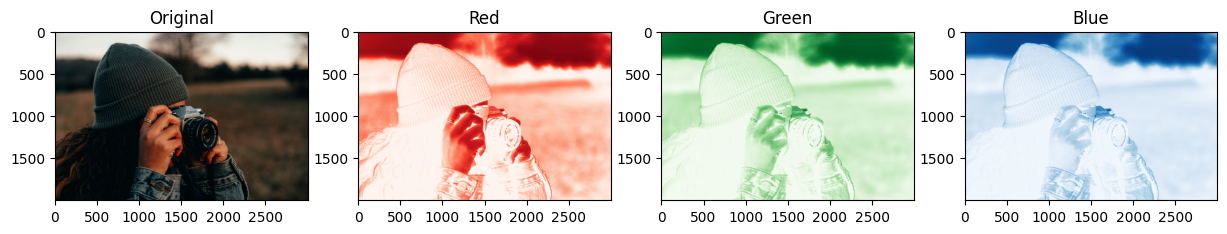

In [ ]:
rgb_img = Image.open("/content/photo-1575936123452-b67c3203c357.jpeg").convert("RGB")
rgb_array = np.array(rgb_img)


# Separate channels
R = rgb_array[:, :, 0]
G = rgb_array[:, :, 1]
B = rgb_array[:, :, 2]

# showing the original image
fig, axs = plt.subplots(1, 4, figsize=(15,5))
axs[0].imshow(rgb_img)
axs[0].set_title("Original")

# showing the red color
axs[1].imshow(R, cmap='Reds')
axs[1].set_title("Red")


#showing green color image
axs[2].imshow(G, cmap='Greens')
axs[2].set_title("Green")


#showing blue color image
axs[3].imshow(B, cmap='Blues')
axs[3].set_title("Blue")


# Convert RGB to Grayscale manually

Text(0.5, 1.0, 'Manual Grayscale')

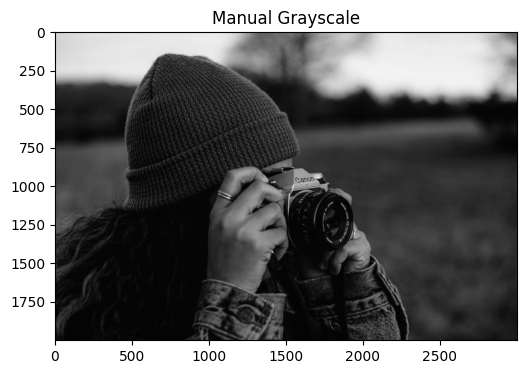

In [ ]:
# Manual conversion
gray_manual = 0.2989 * R + 0.5870 * G + 0.1140 * B
gray_manual = gray_manual.astype(np.uint8)

plt.figure(figsize=(10,4))

plt.imshow(gray_manual, cmap='gray')
plt.title("Manual Grayscale")

Text(0.5, 1.0, 'Built-in Grayscale')

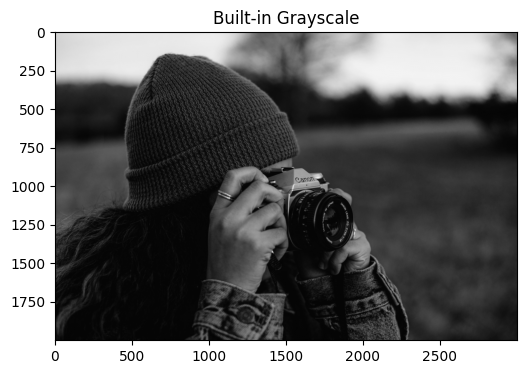

In [ ]:
# build in RGB to Gray

gray_builtin = cv2.cvtColor(rgb_array, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10,4))

plt.imshow(gray_builtin, cmap='gray')
plt.title("Built-in Grayscale")

# Apply a 3x3 Edge Detection Kernel (Sobel or Laplacian)

In [ ]:
# grayscale image
image_path = "/content/photo-1575936123452-b67c3203c357.jpeg"

img = Image.open(image_path).convert("L")  # L = grayscale mode

# Convert to NumPy array
image = np.array(img)

In [ ]:
# Sobel kernel for edge detection (horizontal)
sobel_kernel = np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]])

In [ ]:
def apply_kernel(img, kernel):
    h, w = img.shape
    output = np.zeros((h-2, w-2))
    for i in range(h - 2):
        for j in range(w - 2):
            region = img[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    return output

In [ ]:
# function calling

convolved = apply_kernel(image, sobel_kernel)
convolved

array([[ 1.,  0.,  1., ...,  2.,  1.,  1.],
       [ 2.,  1.,  1., ..., -2., -1.,  0.],
       [ 1.,  2.,  3., ..., -4., -3., -1.],
       ...,
       [-4.,  0.,  0., ..., -4.,  5.,  9.],
       [-4.,  0.,  0., ..., -4.,  7., 12.],
       [-4.,  0.,  0., ..., -3.,  8., 15.]])

Text(0.5, 1.0, 'Original Image')

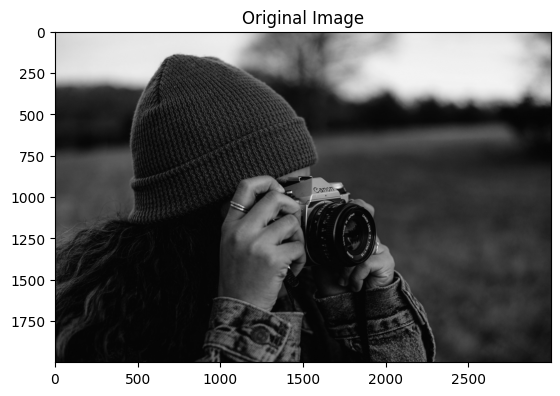

In [ ]:
plt.imshow(image, cmap='gray')
plt.title("Original Image")

Text(0.5, 1.0, 'Convolved Output with Sobel')

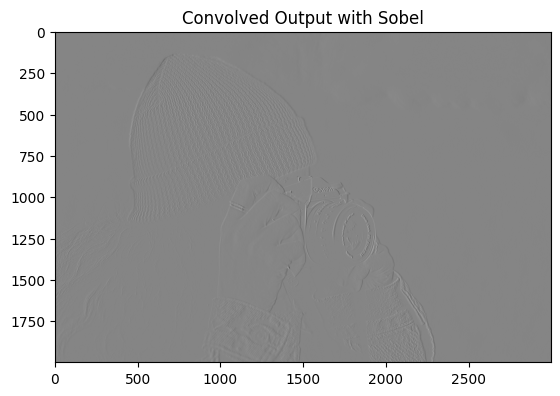

In [ ]:
plt.imshow(convolved, cmap='gray')
plt.title("Convolved Output with Sobel")

# Implement Zero Padding Manually

In [ ]:
# padding maintain the size of the image after applying kernel on it.

def zero_padding(img, pad=1):
    h, w = img.shape
    new_img = np.zeros((h + 2*pad, w + 2*pad))  # applying padding on height and width
    new_img[pad:h+pad, pad:w+pad] = img        # original image into the center of the new zero-padded image.
    return new_img


padded_img = zero_padding(image, pad=1)
print("Shape before:", image.shape, "| After Padding:", padded_img.shape)

Shape before: (2000, 3000) | After Padding: (2002, 3002)


# Apply stride = 2 and observe output size

In [ ]:
# applying stride manually on the image
# stride decrease the size of the feature map.
def convolve_stride(img, kernel, stride=2):
    h, w = img.shape
    kh, kw = kernel.shape
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1    # Formula to compute output size after convolution with stride


    output = np.zeros((out_h, out_w))
    for i in range(0, out_h):
        for j in range(0, out_w):
            region = img[i*stride:i*stride+kh,
                         j*stride:j*stride+kw] #sub-region of the image that matches the size of the kernel.

            output[i, j] = np.sum(region * kernel)
    return output

In [ ]:
stride_output = convolve_stride(image, sobel_kernel, stride=2)
print("Output shape with stride=2:", stride_output.shape)

Output shape with stride=2: (999, 1499)


# Implement and compare Different Kernels

In [ ]:
# Filters
identity = np.array([[0,0,0],
                     [0,1,0],
                     [0,0,0]])


#sharpen kernel/filter
sharpen = np.array([[0,-1,0],
                    [-1,5,-1],
                    [0,-1,0]])

#gaussian filter
gaussian = (1/16)*np.array([[1,2,1],
                            [2,4,2],
                            [1,2,1]])

#vertical edge detector
edge_v = np.array([[-1,0,1],
                   [-2,0,2],
                   [-1,0,1]])

# Horizontal edge detector
edge_h = np.array([[-1,-2,-1],
                   [0,0,0],
                    [1,2,1]])

In [ ]:
def general_convolve(img, kernel, stride=1, pad=0):
    if pad > 0:
        img = zero_padding(img, pad)
    return convolve_stride(img, kernel, stride)

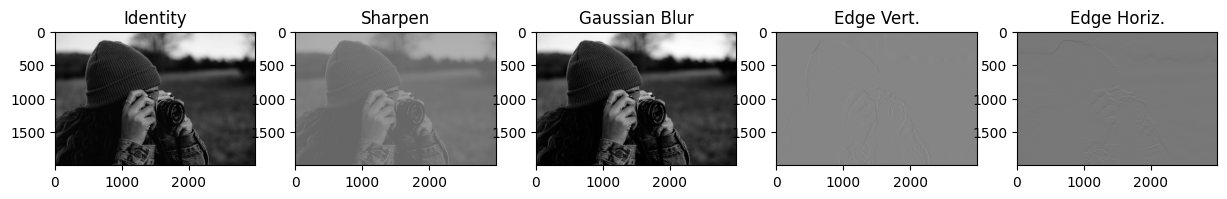

In [ ]:
# Visual Comparison
kernels = [identity, sharpen, gaussian, edge_v, edge_h]
titles = ["Identity", "Sharpen", "Gaussian Blur", "Edge Vert.", "Edge Horiz."]

plt.figure(figsize=(15,5))
for i in range(len(kernels)):
    out = general_convolve(image, kernels[i])
    plt.subplot(1,5,i+1)
    plt.imshow(out, cmap='gray')
    plt.title(titles[i])

**Convolving the same image with different kernels extracts different features: identity shows the original, sharpen enhances details, Gaussian blur smooths textures, vertical edge detects upright lines, and horizontal edge reveals flat structures.**

# Max Pooling Manually


Original: (2000, 3000) | Pooled: (1000, 1500)


Text(0.5, 1.0, 'Max Pooled Image')

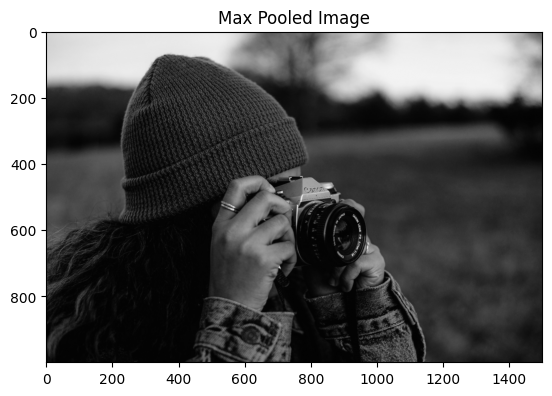

In [ ]:
def max_pool(img, size=2):
    h, w = img.shape
    output = np.zeros((h//size, w//size))
    for i in range(0, h, size):
        for j in range(0, w, size):
            output[i//size, j//size] = np.max(img[i:i+size, j:j+size])
    return output

pooled = max_pool(image, size=2)
print("Original:", image.shape, "| Pooled:", pooled.shape)

plt.imshow(pooled, cmap='gray')
plt.title("Max Pooled Image")
